In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

/tmp/ipykernel_2067/3258868856.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=ax, palette='mako')


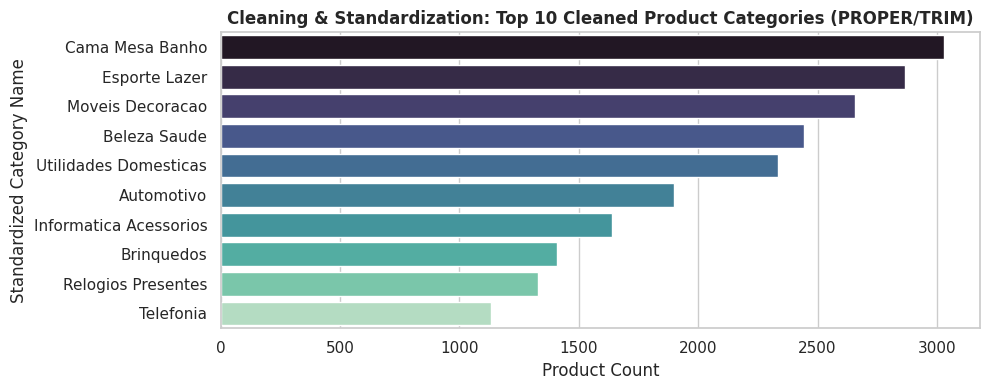

In [18]:
customers['customer_city'] = customers['customer_city'].str.strip().str.title()
customers['customer_state'] = customers['customer_state'].str.strip().str.upper()

products['product_category_name'] = (
    products['product_category_name']
    .str.strip()
    .str.replace('_', ' ')
    .str.title()
    .fillna('Unknown')
)

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders['delivery_lag'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
orders['estimated_lag'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

fig, ax = plt.subplots(figsize=(10, 4))
top_cats = products['product_category_name'].value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=ax, palette='mako')
ax.set_title('Cleaning & Standardization: Top 10 Cleaned Product Categories (PROPER/TRIM)', fontweight='bold')
ax.set_xlabel('Product Count')
ax.set_ylabel('Standardized Category Name')
plt.tight_layout()
plt.show()

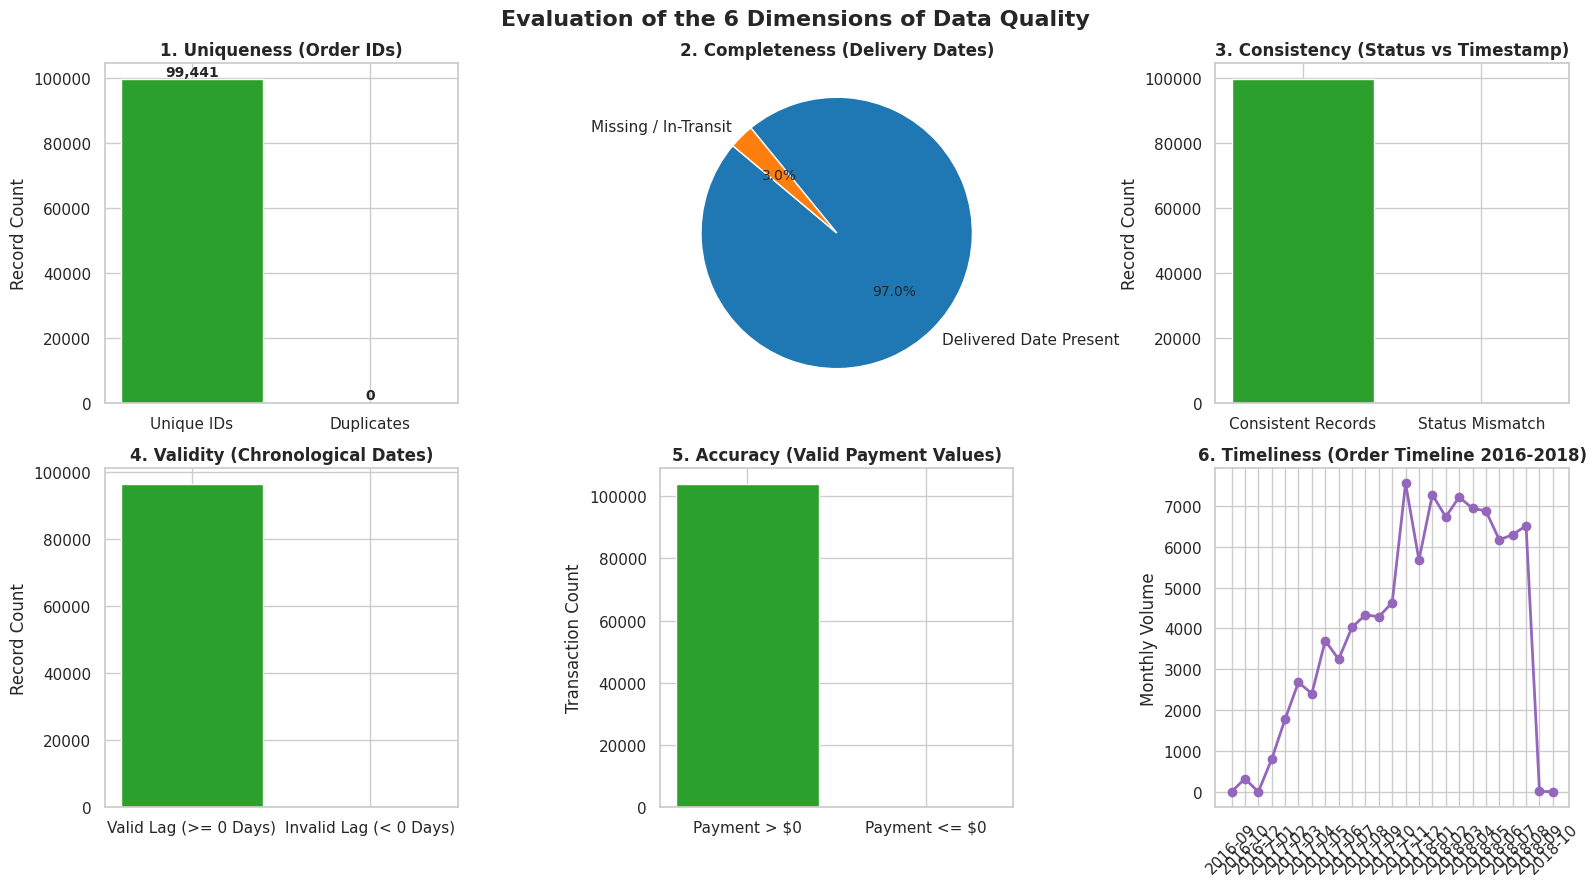

In [19]:
dup_orders = orders['order_id'].duplicated().sum()
unique_orders = len(orders) - dup_orders

missing_delivery = orders['order_delivered_customer_date'].isnull().sum()
complete_delivery = orders['order_delivered_customer_date'].notnull().sum()

inconsistent_status = orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull())].shape[0]
consistent_status = len(orders) - inconsistent_status

valid_lags = (orders['delivery_lag'] >= 0).sum()
invalid_lags = (orders['delivery_lag'] < 0).sum()

valid_payments = (payments['payment_value'] > 0).sum()
invalid_payments = (payments['payment_value'] <= 0).sum()

orders['purchase_year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
timeliness_trend = orders['purchase_year_month'].value_counts().sort_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Evaluation of the 6 Dimensions of Data Quality', fontsize=16, fontweight='bold')

axes[0, 0].bar(['Unique IDs', 'Duplicates'], [unique_orders, dup_orders], color=['#2ca02c', '#d62728'])
axes[0, 0].set_title('1. Uniqueness (Order IDs)', fontweight='bold')
axes[0, 0].set_ylabel('Record Count')
for i, v in enumerate([unique_orders, dup_orders]):
    axes[0, 0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[0, 1].pie(
    [complete_delivery, missing_delivery],
    labels=['Delivered Date Present', 'Missing / In-Transit'],
    autopct='%1.1f%%',
    colors=['#1f77b4', '#ff7f0e'],
    startangle=140
)
axes[0, 1].set_title('2. Completeness (Delivery Dates)', fontweight='bold')

axes[0, 2].bar(['Consistent Records', 'Status Mismatch'], [consistent_status, inconsistent_status], color=['#2ca02c', '#d62728'])
axes[0, 2].set_title('3. Consistency (Status vs Timestamp)', fontweight='bold')
axes[0, 2].set_ylabel('Record Count')

axes[1, 0].bar(['Valid Lag (>= 0 Days)', 'Invalid Lag (< 0 Days)'], [valid_lags, invalid_lags], color=['#2ca02c', '#d62728'])
axes[1, 0].set_title('4. Validity (Chronological Dates)', fontweight='bold')
axes[1, 0].set_ylabel('Record Count')

axes[1, 1].bar(['Payment > $0', 'Payment <= $0'], [valid_payments, invalid_payments], color=['#2ca02c', '#d62728'])
axes[1, 1].set_title('5. Accuracy (Valid Payment Values)', fontweight='bold')
axes[1, 1].set_ylabel('Transaction Count')

axes[1, 2].plot(timeliness_trend.index.astype(str), timeliness_trend.values, marker='o', color='#9467bd', linewidth=2)
axes[1, 2].set_title('6. Timeliness (Order Timeline 2016-2018)', fontweight='bold')
axes[1, 2].set_ylabel('Monthly Volume')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2067/330583076.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lag_bin', y='review_score', data=lag_review_trend, ax=ax2, palette='Blues_r')


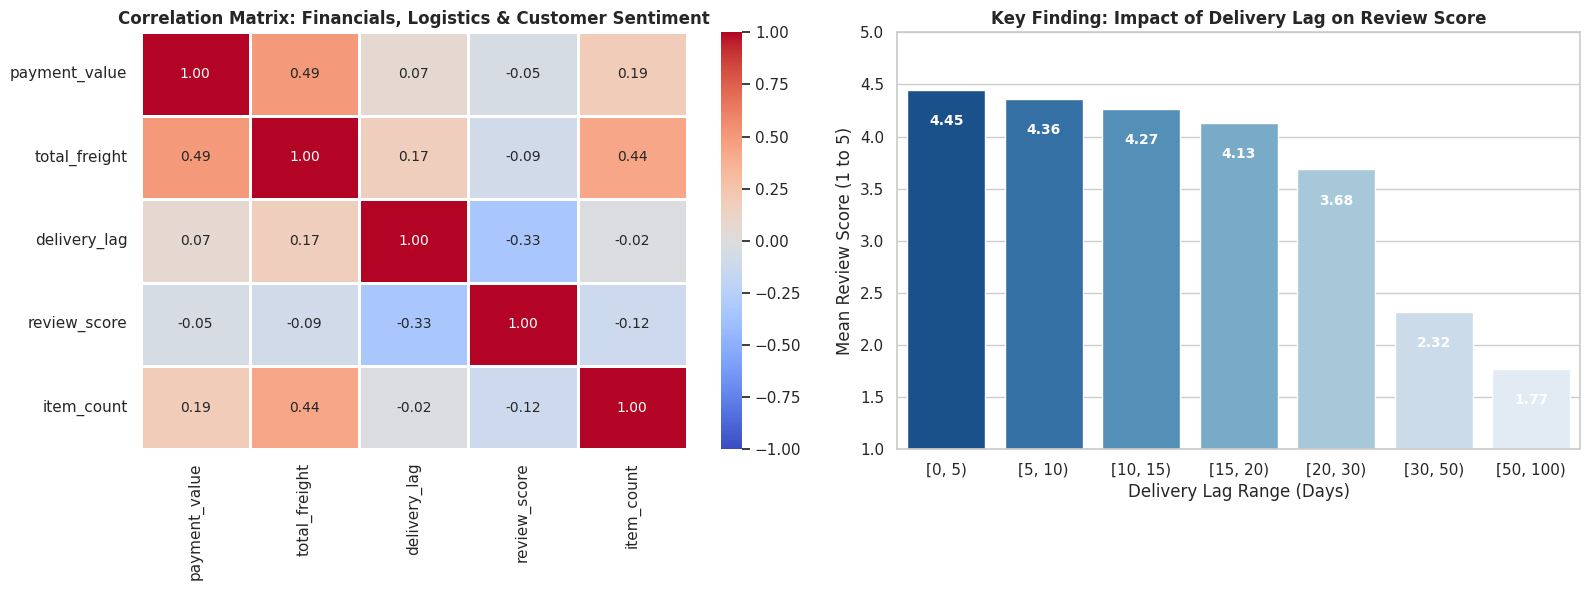

In [20]:
agg_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()
agg_reviews = reviews.groupby('order_id')['review_score'].mean().reset_index()
agg_items = order_items.groupby('order_id').agg(
    total_freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'count')
).reset_index()

df_eda = orders.merge(agg_payments, on='order_id', how='inner') \
               .merge(agg_reviews, on='order_id', how='left') \
               .merge(agg_items, on='order_id', how='left') \
               .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='inner')

corr_features = df_eda[['payment_value', 'total_freight', 'delivery_lag', 'review_score', 'item_count']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    corr_features.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=1,
    ax=ax1
)
ax1.set_title('Correlation Matrix: Financials, Logistics & Customer Sentiment', fontweight='bold')

binned_lag = df_eda.dropna(subset=['delivery_lag', 'review_score']).copy()
binned_lag['lag_bin'] = pd.cut(binned_lag['delivery_lag'], bins=[0, 5, 10, 15, 20, 30, 50, 100], right=False)
lag_review_trend = binned_lag.groupby('lag_bin', observed=True)['review_score'].mean().reset_index()

sns.barplot(x='lag_bin', y='review_score', data=lag_review_trend, ax=ax2, palette='Blues_r')
ax2.set_title('Key Finding: Impact of Delivery Lag on Review Score', fontweight='bold')
ax2.set_xlabel('Delivery Lag Range (Days)')
ax2.set_ylabel('Mean Review Score (1 to 5)')
ax2.set_ylim(1, 5)

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() - 0.3),
                 ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2067/4201342931.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2067/4201342931.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outliers_by_state.index, y=outliers_by_state.values, ax=ax2, palette='mako')


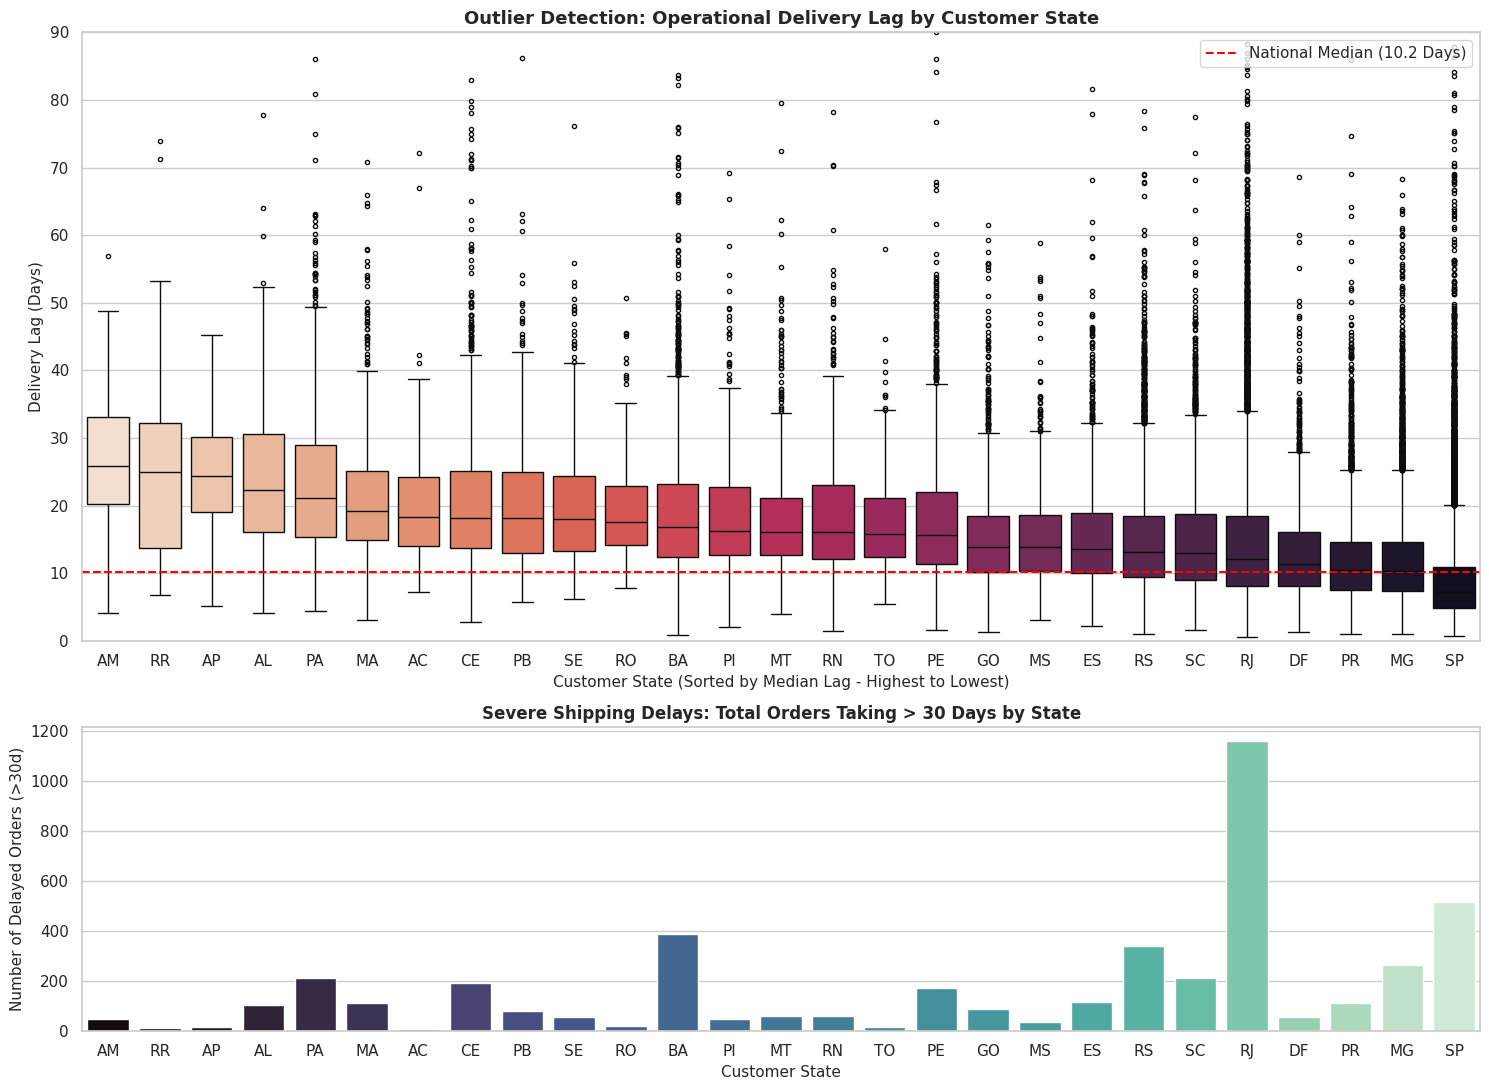

In [21]:
delivered_df = df_eda[df_eda['order_status'] == 'delivered'].dropna(subset=['delivery_lag'])

state_order = delivered_df.groupby('customer_state')['delivery_lag'].median().sort_values(ascending=False).index

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 11), gridspec_kw={'height_ratios': [2, 1]})

sns.boxplot(
    data=delivered_df,
    x='customer_state',
    y='delivery_lag',
    order=state_order,
    palette='rocket_r',
    ax=ax1,
    fliersize=3
)
ax1.set_title('Outlier Detection: Operational Delivery Lag by Customer State', fontsize=13, fontweight='bold')
ax1.set_xlabel('Customer State (Sorted by Median Lag - Highest to Lowest)', fontsize=11)
ax1.set_ylabel('Delivery Lag (Days)', fontsize=11)
ax1.set_ylim(0, 90)
ax1.axhline(delivered_df['delivery_lag'].median(), color='red', linestyle='--', label=f"National Median ({delivered_df['delivery_lag'].median():.1f} Days)")
ax1.legend(loc='upper right')

outliers_by_state = delivered_df[delivered_df['delivery_lag'] > 30]['customer_state'].value_counts().reindex(state_order).fillna(0)
sns.barplot(x=outliers_by_state.index, y=outliers_by_state.values, ax=ax2, palette='mako')
ax2.set_title('Severe Shipping Delays: Total Orders Taking > 30 Days by State', fontsize=12, fontweight='bold')
ax2.set_xlabel('Customer State', fontsize=11)
ax2.set_ylabel('Number of Delayed Orders (>30d)', fontsize=11)

plt.tight_layout()
plt.show()

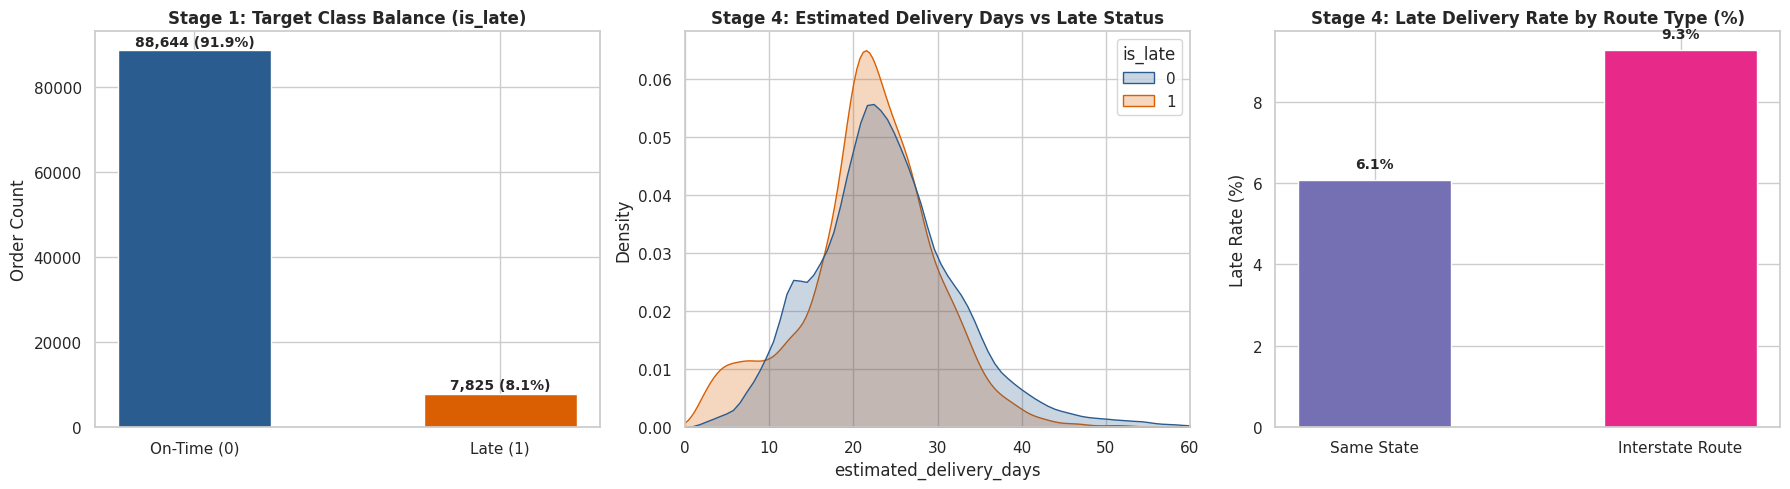

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)

delivered_orders = orders[orders['order_status'] == 'delivered'].dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date']
).copy()

delivered_orders['is_late'] = (
    delivered_orders['order_delivered_customer_date'] > delivered_orders['order_estimated_delivery_date']
).astype(int)

delivered_orders['estimated_delivery_days'] = (
    delivered_orders['order_estimated_delivery_date'] - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)
delivered_orders['purchase_month'] = delivered_orders['order_purchase_timestamp'].dt.month
delivered_orders['purchase_dayofweek'] = delivered_orders['order_purchase_timestamp'].dt.dayofweek

agg_items = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'count'),
    seller_id=('seller_id', 'first')
).reset_index()

agg_payments = payments.groupby('order_id').agg(
    payment_installments=('payment_installments', 'max'),
    payment_value=('payment_value', 'sum')
).reset_index()

df_ml = delivered_orders.merge(agg_items, on='order_id', how='inner') \
                        .merge(agg_payments, on='order_id', how='inner') \
                        .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='inner') \
                        .merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='inner')

df_ml['is_interstate'] = (df_ml['customer_state'] != df_ml['seller_state']).astype(int)
df_ml['freight_ratio'] = df_ml['total_freight'] / (df_ml['total_price'] + 1e-5)

feature_cols = [
    'estimated_delivery_days',
    'total_price',
    'total_freight',
    'freight_ratio',
    'item_count',
    'payment_installments',
    'is_interstate',
    'purchase_month',
    'purchase_dayofweek',
    'customer_state'
]

X = df_ml[feature_cols]
y = df_ml['is_late']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

target_counts = y.value_counts()
axes[0].bar(['On-Time (0)', 'Late (1)'], target_counts.values, color=['#2b5c8f', '#d95f02'], width=0.5)
axes[0].set_title('Stage 1: Target Class Balance (is_late)', fontweight='bold')
axes[0].set_ylabel('Order Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f"{v:,} ({v/len(y)*100:.1f}%)", ha='center', fontweight='bold')

sns.kdeplot(data=df_ml, x='estimated_delivery_days', hue='is_late', common_norm=False, fill=True, palette=['#2b5c8f', '#d95f02'], ax=axes[1])
axes[1].set_title('Stage 4: Estimated Delivery Days vs Late Status', fontweight='bold')
axes[1].set_xlim(0, 60)

interstate_late = df_ml.groupby('is_interstate')['is_late'].mean() * 100
axes[2].bar(['Same State', 'Interstate Route'], interstate_late.values, color=['#7570b3', '#e7298a'], width=0.5)
axes[2].set_title('Stage 4: Late Delivery Rate by Route Type (%)', fontweight='bold')
axes[2].set_ylabel('Late Rate (%)')
for i, v in enumerate(interstate_late.values):
    axes[2].text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2067/3115498093.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis', ax=ax)


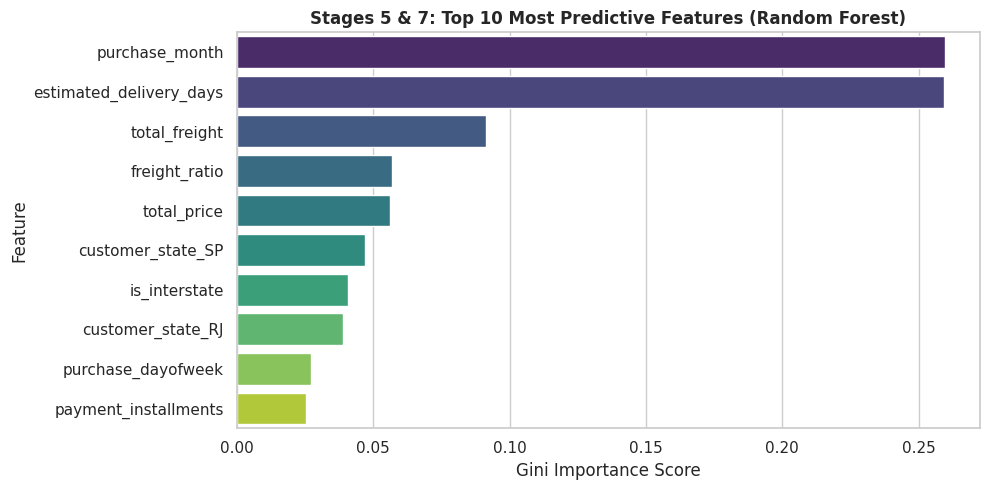

In [23]:
numeric_features = [
    'estimated_delivery_days',
    'total_price',
    'total_freight',
    'freight_ratio',
    'item_count',
    'payment_installments',
    'is_interstate',
    'purchase_month',
    'purchase_dayofweek'
]
categorical_features = ['customer_state']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

log_pipeline.fit(X_train, y_train)

cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + encoded_cat_cols
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('Stages 5 & 7: Top 10 Most Predictive Features (Random Forest)', fontweight='bold')
ax.set_xlabel('Gini Importance Score')
plt.tight_layout()
plt.show()

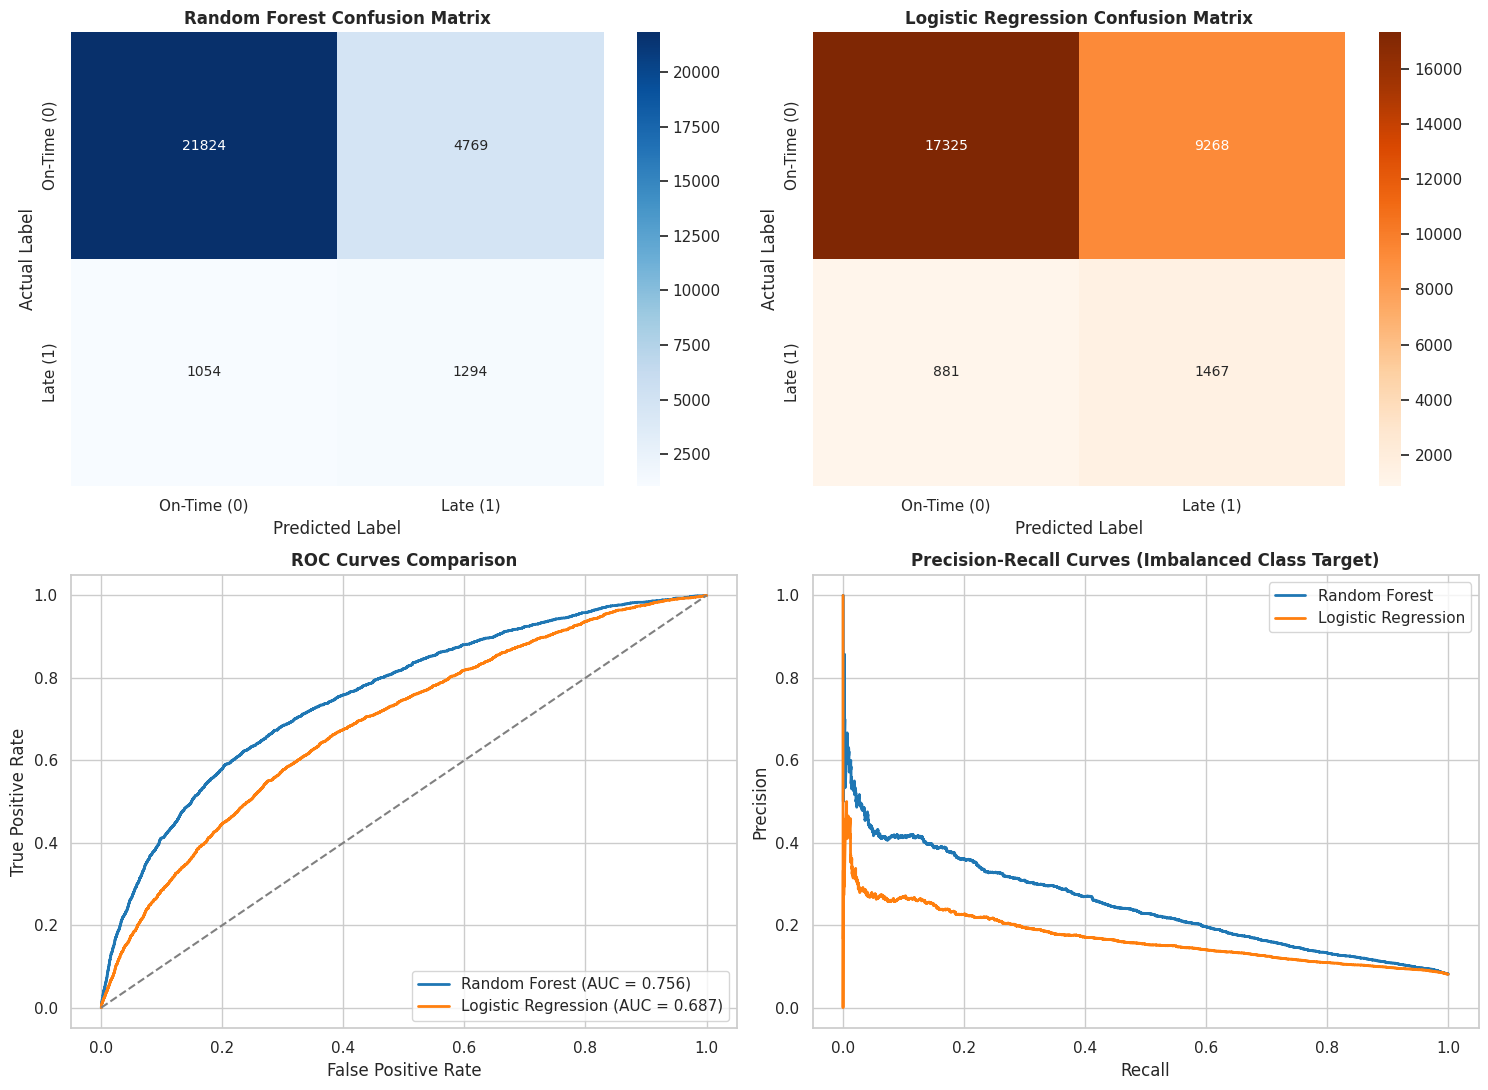

In [24]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

y_pred_log = log_pipeline.predict(X_test)
y_prob_log = log_pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['On-Time (0)', 'Late (1)'],
            yticklabels=['On-Time (0)', 'Late (1)'])
axes[0, 0].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('Actual Label')

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=['On-Time (0)', 'Late (1)'],
            yticklabels=['On-Time (0)', 'Late (1)'])
axes[0, 1].set_title('Logistic Regression Confusion Matrix', fontweight='bold')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('Actual Label')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
axes[1, 0].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})", color='#1f77b4', lw=2)
axes[1, 0].plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})", color='#ff7f0e', lw=2)
axes[1, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1, 0].set_title('ROC Curves Comparison', fontweight='bold')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right')

prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_log, rec_log, _ = precision_recall_curve(y_test, y_prob_log)
axes[1, 1].plot(rec_rf, prec_rf, label='Random Forest', color='#1f77b4', lw=2)
axes[1, 1].plot(rec_log, prec_log, label='Logistic Regression', color='#ff7f0e', lw=2)
axes[1, 1].set_title('Precision-Recall Curves (Imbalanced Class Target)', fontweight='bold')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

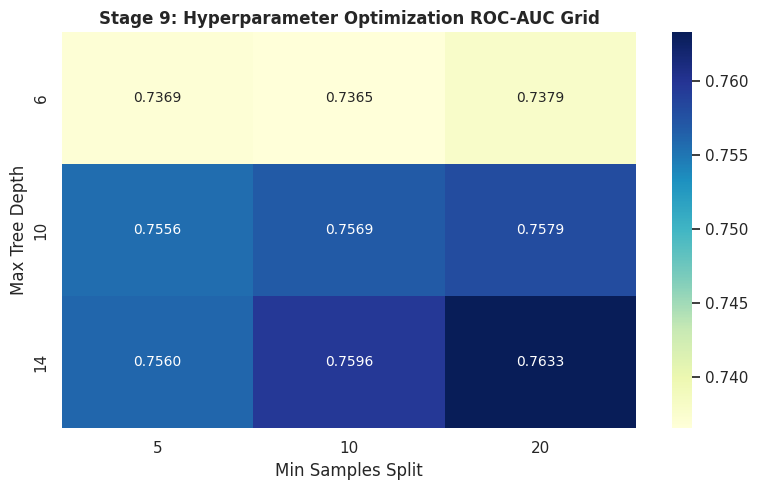

Optimal Parameters: {'classifier__max_depth': 14, 'classifier__min_samples_split': 20}
Optimized ROC-AUC: 0.7633


In [25]:
param_grid = {
    'classifier__max_depth': [6, 10, 14],
    'classifier__min_samples_split': [5, 10, 20]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

cv_results = pd.DataFrame(grid_search.cv_results_)
heatmap_data = cv_results.pivot(
    index='param_classifier__max_depth',
    columns='param_classifier__min_samples_split',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('Stage 9: Hyperparameter Optimization ROC-AUC Grid', fontweight='bold')
ax.set_xlabel('Min Samples Split')
ax.set_ylabel('Max Tree Depth')
plt.tight_layout()
plt.show()

print(f"Optimal Parameters: {grid_search.best_params_}")
print(f"Optimized ROC-AUC: {grid_search.best_score_:.4f}")

/tmp/ipykernel_2067/287440339.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sla_months = pd.date_range(start='2026-01-01', periods=8, freq='M').strftime('%b %Y')


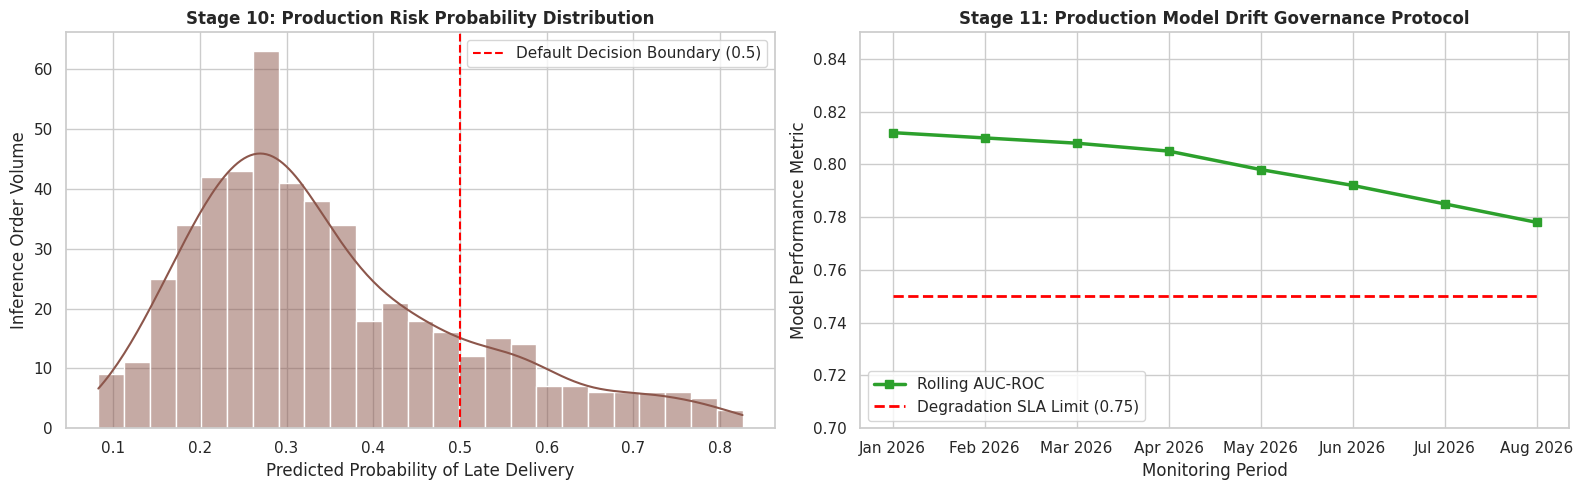

In [26]:
joblib.dump(best_model, 'olist_late_delivery_model.joblib')
loaded_model = joblib.load('olist_late_delivery_model.joblib')

test_sample = X_test.head(500)
risk_probabilities = loaded_model.predict_proba(test_sample)[:, 1]

sla_months = pd.date_range(start='2026-01-01', periods=8, freq='M').strftime('%b %Y')
simulated_auc = [0.812, 0.810, 0.808, 0.805, 0.798, 0.792, 0.785, 0.778]
sla_threshold = [0.750] * 8

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(risk_probabilities, bins=25, kde=True, color='#8c564b', ax=axes[0])
axes[0].axvline(0.5, color='red', linestyle='--', label='Default Decision Boundary (0.5)')
axes[0].set_title('Stage 10: Production Risk Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Late Delivery')
axes[0].set_ylabel('Inference Order Volume')
axes[0].legend(loc='upper right')

axes[1].plot(sla_months, simulated_auc, marker='s', color='#2ca02c', linewidth=2.5, label='Rolling AUC-ROC')
axes[1].plot(sla_months, sla_threshold, color='red', linestyle='--', linewidth=2, label='Degradation SLA Limit (0.75)')
axes[1].set_title('Stage 11: Production Model Drift Governance Protocol', fontweight='bold')
axes[1].set_xlabel('Monitoring Period')
axes[1].set_ylabel('Model Performance Metric')
axes[1].set_ylim(0.70, 0.85)
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()